In [13]:
import pandas as pd
import os
import polars as pl
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import torch
import gc
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from tqdm.auto import tqdm

DATA_PATH = '/kaggle/input/datasets/nikolasking/favorita'

In [4]:
train_sample = pd.read_csv(os.path.join(DATA_PATH, 'train.csv'), nrows=100000, parse_dates=['date'])
train_sample.isna().sum()

id                  0
date                0
store_nbr           0
item_nbr            0
unit_sales          0
onpromotion    100000
dtype: int64

In [7]:
train_sample.dtypes

id                      int64
date           datetime64[ns]
store_nbr               int64
item_nbr                int64
unit_sales            float64
onpromotion           float64
dtype: object

In [8]:
train_sample.head()

,id,date,store_nbr,item_nbr,unit_sales,onpromotion
0,0,2013-01-01,25,103665,7.0,NaN
1,1,2013-01-01,25,105574,1.0,NaN
2,2,2013-01-01,25,105575,2.0,NaN
3,3,2013-01-01,25,108079,1.0,NaN
4,4,2013-01-01,25,108701,1.0,NaN


In [11]:
def meta(df):
    df = pd.read_csv(os.path.join(DATA_PATH, f'{df}.csv'))
    print("Shape:", df.shape)
    print("\nТипы данных:\n", df.dtypes)
    print("\nПервые 5 строк:\n", df.head())
    print("\nПропуски: ", df.isna().sum().sum())
    print("\nУникальные значения:\n")
    for col in df.columns:
        print(f"{col}:", df[col].nunique())
        print()

datasets = ['stores', 'items', 'oil', 'holidays_events']
for i in datasets:
    print(f'=== {i} ===')
    meta(i)

=== stores ===
Shape: (54, 5)

Типы данных:
 store_nbr     int64
city         object
state        object
type         object
cluster       int64
dtype: object

Первые 5 строк:
    store_nbr           city                           state type  cluster
0          1          Quito                       Pichincha    D       13
1          2          Quito                       Pichincha    D       13
2          3          Quito                       Pichincha    D        8
3          4          Quito                       Pichincha    D        9
4          5  Santo Domingo  Santo Domingo de los Tsachilas    D        4

Пропуски:  0

Уникальные значения:

store_nbr: 54

city: 22

state: 16

type: 5

cluster: 17

=== items ===
Shape: (4100, 4)

Типы данных:
 item_nbr       int64
family        object
class          int64
perishable     int64
dtype: object

Первые 5 строк:
    item_nbr        family  class  perishable
0     96995     GROCERY I   1093           0
1     99197     GROCERY I   1067

### >>> посмотрели на данные, теперь корректно их загрузим

In [46]:
import polars as pl
import os

DATA_PATH = "/kaggle/input/datasets/nikolasking/favorita/"

def load_clean_merged_df(base_path):
    stores = pl.read_csv(os.path.join(base_path, "stores.csv")).select([
        pl.col("store_nbr").cast(pl.Int8),
        pl.col("city").cast(pl.Categorical),
        pl.col("state").cast(pl.Categorical),
        pl.col("type").alias("store_type").cast(pl.Categorical),
        pl.col("cluster").cast(pl.Int8)
    ])
    
    items = pl.read_csv(os.path.join(base_path, "items.csv")).select([
        pl.col("item_nbr").cast(pl.Int32),
        pl.col("family").cast(pl.Categorical),
        pl.col("class").cast(pl.Int16),
        pl.col("perishable").cast(pl.Int8)
    ])
    
    oil = pl.read_csv(os.path.join(base_path, "oil.csv"), try_parse_dates=True).cast({
        "dcoilwtico": pl.Float32
    })
    
    holidays = (
        pl.read_csv(os.path.join(base_path, "holidays_events.csv"), try_parse_dates=True)
        .unique(subset=["date"])
        .rename({"type": "holiday_type"})
    )

    # Загрузка основного train (2017 год) - будь брать именно данный год, чтобы избежать возможных неприятностей с аномалией 2016 года
    train_2017 = (
        pl.scan_csv(os.path.join(base_path, "train.csv"), try_parse_dates=True)
        .filter(pl.col("date") >= pl.date(2017, 1, 1))
        .with_columns([
            pl.col("unit_sales").clip(lower_bound=0).cast(pl.Float32),
            pl.col("store_nbr").cast(pl.Int8),
            pl.col("item_nbr").cast(pl.Int32),
            # Явная логика преобразования строки в число 0/1
            pl.when(pl.col("onpromotion") == "True")
              .then(1)
              .otherwise(0)
              .cast(pl.Int8)
              .alias("onpromotion")
        ])
        .collect()
    )

    df = (
        train_2017
        .join(items, on="item_nbr", how="left")
        .join(stores, on="store_nbr", how="left")
        .join(oil, on="date", how="left")
        .join(holidays, on="date", how="left")
    )

    return df, stores, items, oil, holidays

# Выполняем сборку
df_clean, stores, items, oil, holidays= load_clean_merged_df(DATA_PATH)

print(f"Итого строк: {df_clean.height}")
print(df_clean.select(["date", "store_nbr", "item_nbr", "onpromotion"]).head())

Итого строк: 23808261
shape: (5, 4)
┌────────────┬───────────┬──────────┬─────────────┐
│ date       ┆ store_nbr ┆ item_nbr ┆ onpromotion │
│ ---        ┆ ---       ┆ ---      ┆ ---         │
│ date       ┆ i8        ┆ i32      ┆ i8          │
╞════════════╪═══════════╪══════════╪═════════════╡
│ 2017-01-01 ┆ 25        ┆ 99197    ┆ 0           │
│ 2017-01-01 ┆ 25        ┆ 103665   ┆ 0           │
│ 2017-01-01 ┆ 25        ┆ 105574   ┆ 0           │
│ 2017-01-01 ┆ 25        ┆ 105857   ┆ 0           │
│ 2017-01-01 ┆ 25        ┆ 106716   ┆ 0           │
└────────────┴───────────┴──────────┴─────────────┘


In [47]:
# Проверка на дубликаты по бизнес-ключам
# Если количество уникальных сочетаний равно общему количеству строк, дублей нет
business_keys = ["date", "store_nbr", "item_nbr"]
total_rows = df_clean.height
unique_keys_count = df_clean.select(business_keys).n_unique()

print(f"Всего строк: {total_rows}")
print(f"Уникальных ключей: {unique_keys_count}")
if total_rows == unique_keys_count:
    print("Дубликатов по ключам [date, store, item] нет.")
else:
    print(f"Найдено {total_rows - unique_keys_count} дубликатов!")

Всего строк: 23808261
Уникальных ключей: 23808261
Дубликатов по ключам [date, store, item] нет.


In [48]:
print("\nКоличество пропусков (Nulls) по колонкам:")
null_counts = df_clean.null_count()
for col in df_clean.columns:
    count = null_counts[col][0]
    percentage = (count / total_rows) * 100
    if count > 0:
        print(f"{col}: {count} ({percentage:.2f}%)")
    else:
        print(f"{col}: 0 (Чисто)")


Количество пропусков (Nulls) по колонкам:
id: 0 (Чисто)
date: 0 (Чисто)
store_nbr: 0 (Чисто)
item_nbr: 0 (Чисто)
unit_sales: 0 (Чисто)
onpromotion: 0 (Чисто)
family: 0 (Чисто)
class: 0 (Чисто)
perishable: 0 (Чисто)
city: 0 (Чисто)
state: 0 (Чисто)
store_type: 0 (Чисто)
cluster: 0 (Чисто)
dcoilwtico: 7901470 (33.19%)
holiday_type: 21138337 (88.79%)
locale: 21138337 (88.79%)
locale_name: 21138337 (88.79%)
description: 21138337 (88.79%)
transferred: 21138337 (88.79%)


In [49]:
# Проверка на бесконечные значения (на всякий случай для float колонок)
print("\nПроверка на Inf в продажах:")
inf_count = df_clean.filter(pl.col("unit_sales").is_infinite()).height
print(f"Infinity в unit_sales: {inf_count}")


Проверка на Inf в продажах:
Infinity в unit_sales: 0


In [50]:
df_clean = df_clean.with_columns([
    # Нефть: заполняем пропуски (вперед, затем назад для 1 января)
    pl.col("dcoilwtico").fill_null(strategy="forward").fill_null(strategy="backward"),
    
    # Праздники: текстовые колонки -> "None", булевы -> False
    pl.col("holiday_type").fill_null("None").cast(pl.Categorical),
    pl.col("locale").fill_null("None").cast(pl.Categorical),
    pl.col("locale_name").fill_null("None").cast(pl.Categorical),
    pl.col("description").fill_null("None").cast(pl.Categorical),
    pl.col("transferred").fill_null(False)
])

# проверка на пропуски (считаем сумму Null по всему DataFrame)
null_sum = df_clean.null_count().select(pl.all().sum()).row(0)
total_nulls = sum(null_sum)

print(f"Общее количество пропусков в таблице: {total_nulls}")

Общее количество пропусков в таблице: 0


In [51]:
def prepare_ml_features(train_df, items_df, stores_df, oil_df, holidays_df, is_test=False):
    # LazyFrame для оптимизации
    ldf = train_df.lazy()
    
    # Логирование таргета
    if not is_test:
        ldf = ldf.with_columns(
            pl.col('unit_sales').clip(lower_bound=0).log1p().alias('log_unit_sales')
        )

    # Присоединяем справочники
    ldf = ldf.join(items_df.lazy(), on='item_nbr', how='left')
    ldf = ldf.join(stores_df.lazy(), on='store_nbr', how='left')

    # Праздники (агрегация до 1 флага на дату)
    holidays_clean = (
        holidays_df.lazy()
        .filter(pl.col('transferred') == False)
        .group_by('date')
        .agg(pl.lit(1).alias('is_holiday').cast(pl.Int8))
    )
    ldf = ldf.join(holidays_clean, on='date', how='left').with_columns(
        pl.col('is_holiday').fill_null(0)
    )

    # Нефть и лаги по нефти
    oil_features = (
        oil_df.lazy()
        .with_columns(pl.col('dcoilwtico').fill_null(strategy='forward'))
        .with_columns([
            pl.col('dcoilwtico').shift(1).alias('oil_lag1'),
            pl.col('dcoilwtico').rolling_mean(window_size=7).alias('oil_roll_mean7')
        ])
    )
    ldf = ldf.join(oil_features, on='date', how='left')

    # Временные признаки (с твоим исправлением payroll)
    ldf = ldf.with_columns([
        pl.col('date').dt.month().alias('month').cast(pl.Int8),
        pl.col('date').dt.weekday().alias('day_of_week').cast(pl.Int8),
        pl.col('date').dt.day().alias('day_of_month').cast(pl.Int8),
        # Выходные
        (pl.col('date').dt.weekday() >= 6).cast(pl.Int8).alias('is_weekend'),
        ((pl.col('date').dt.day() == 15) | (pl.col('date') == pl.col('date').dt.month_end()))
            .cast(pl.Int8).alias('is_payroll'),
        # Декабрь
        (pl.col('date').dt.month() == 12).cast(pl.Int8).alias('is_december')
    ])

    # Лаги и скользящие (Window functions)
    ldf = ldf.sort(['store_nbr', 'item_nbr', 'date'])
    
    ldf = ldf.with_columns([
        # Лаги продаж (за 16 дней - начало теста)
        pl.col('log_unit_sales').shift(16).over(['store_nbr', 'item_nbr']).alias('lag_16'),
        pl.col('log_unit_sales').shift(21).over(['store_nbr', 'item_nbr']).alias('lag_21'),
        # Скользящее среднее (тренд)
        pl.col('log_unit_sales').shift(16)
            .rolling_mean(window_size=28)
            .over(['store_nbr', 'item_nbr'])
            .alias('rolling_mean_28'),
        # Лаг по промо
        pl.col('onpromotion').shift(16).over(['store_nbr', 'item_nbr']).alias('promo_lag_16')
    ])

    # Чистка Null и оптимизация типов
    # Оставляем категориальные признаки как есть, кастим только числа
    return ldf.drop_nulls(subset=['lag_16']).with_columns([
        pl.col(pl.Float64).cast(pl.Float32),
        pl.col(pl.Int64).cast(pl.Int32)
    ])

In [52]:
# Запускаем финальную сборку
final_ml_df = prepare_ml_features(
    df_clean, # Наша очищенная таблица
    items, 
    stores, 
    oil, 
    holidays
).collect()

print(f"Готово! Строк: {final_ml_df.height}")
print(final_ml_df.head())

Готово! Строк: 21194498
shape: (5, 41)
┌───────────┬────────────┬───────────┬──────────┬───┬──────────┬────────┬─────────────┬────────────┐
│ id        ┆ date       ┆ store_nbr ┆ item_nbr ┆ … ┆ lag_16   ┆ lag_21 ┆ rolling_mea ┆ promo_lag_ │
│ ---       ┆ ---        ┆ ---       ┆ ---      ┆   ┆ ---      ┆ ---    ┆ n_28        ┆ 16         │
│ i32       ┆ date       ┆ i8        ┆ i32      ┆   ┆ f32      ┆ f32    ┆ ---         ┆ ---        │
│           ┆            ┆           ┆          ┆   ┆          ┆        ┆ f32         ┆ i8         │
╞═══════════╪════════════╪═══════════╪══════════╪═══╪══════════╪════════╪═════════════╪════════════╡
│ 120438173 ┆ 2017-06-29 ┆ 1         ┆ 96995    ┆ … ┆ 1.098612 ┆ null   ┆ null        ┆ 0          │
│ 122767612 ┆ 2017-07-21 ┆ 1         ┆ 96995    ┆ … ┆ 0.693147 ┆ null   ┆ null        ┆ 0          │
│ 122869722 ┆ 2017-07-22 ┆ 1         ┆ 96995    ┆ … ┆ 1.098612 ┆ null   ┆ null        ┆ 0          │
│ 123819696 ┆ 2017-07-31 ┆ 1         ┆ 96995    ┆ … 

In [53]:
# Посмотрим на строки, где lag_21 пустой
check_nulls = final_ml_df.filter(pl.col("lag_21").is_null()).head(10)

# Выберем один магазин и товар из тех, что имеют null, 
# и посмотрим на их историю в хронологическом порядке
sample_store = check_nulls["store_nbr"][0]
sample_item = check_nulls["item_nbr"][0]

print(f"Анализируем историю для Магазина {sample_store}, Товара {sample_item}:")
history = (
    final_ml_df
    .filter((pl.col("store_nbr") == sample_store) & (pl.col("item_nbr") == sample_item))
    .sort("date")
    .select(["date", "log_unit_sales", "lag_16", "lag_21", "rolling_mean_28"])
)
print(history.head(15))

Анализируем историю для Магазина 1, Товара 96995:
shape: (9, 5)
┌────────────┬────────────────┬──────────┬──────────┬─────────────────┐
│ date       ┆ log_unit_sales ┆ lag_16   ┆ lag_21   ┆ rolling_mean_28 │
│ ---        ┆ ---            ┆ ---      ┆ ---      ┆ ---             │
│ date       ┆ f32            ┆ f32      ┆ f32      ┆ f32             │
╞════════════╪════════════════╪══════════╪══════════╪═════════════════╡
│ 2017-06-29 ┆ 0.693147       ┆ 1.098612 ┆ null     ┆ null            │
│ 2017-07-21 ┆ 1.386294       ┆ 0.693147 ┆ null     ┆ null            │
│ 2017-07-22 ┆ 1.098612       ┆ 1.098612 ┆ null     ┆ null            │
│ 2017-07-31 ┆ 1.098612       ┆ 1.386294 ┆ null     ┆ null            │
│ 2017-08-02 ┆ 0.693147       ┆ 0.693147 ┆ null     ┆ null            │
│ 2017-08-03 ┆ 1.098612       ┆ 0.693147 ┆ 1.098612 ┆ null            │
│ 2017-08-06 ┆ 1.098612       ┆ 0.693147 ┆ 0.693147 ┆ null            │
│ 2017-08-07 ┆ 1.098612       ┆ 0.693147 ┆ 1.098612 ┆ null            │


Интерполировать (соединять точки) здесь нельзя — между продажами могут быть недели тишины. Заполнять средним по всему году значит дать модели «подсмотреть» будущие продажи. Лучшее решение - заполнить нулем.

In [54]:
# 1. Заполняем технические лаги нулями
final_ml_df = final_ml_df.with_columns([
    pl.col("lag_21").fill_null(0),
    pl.col("rolling_mean_28").fill_null(0),
    pl.col("promo_lag_16").fill_null(0)
])

In [55]:
null_counts = final_ml_df.null_count()
for col in final_ml_df.columns:
    count = null_counts[col][0]
    percentage = (count / total_rows) * 100
    if count > 0:
        print(f"{col}: {count} ({percentage:.2f}%)")
    else:
        print(f"{col}: 0 (Чисто)")

id: 0 (Чисто)
date: 0 (Чисто)
store_nbr: 0 (Чисто)
item_nbr: 0 (Чисто)
unit_sales: 0 (Чисто)
onpromotion: 0 (Чисто)
family: 0 (Чисто)
class: 0 (Чисто)
perishable: 0 (Чисто)
city: 0 (Чисто)
state: 0 (Чисто)
store_type: 0 (Чисто)
cluster: 0 (Чисто)
dcoilwtico: 0 (Чисто)
holiday_type: 0 (Чисто)
locale: 0 (Чисто)
locale_name: 0 (Чисто)
description: 0 (Чисто)
transferred: 0 (Чисто)
log_unit_sales: 0 (Чисто)
family_right: 0 (Чисто)
class_right: 0 (Чисто)
perishable_right: 0 (Чисто)
city_right: 0 (Чисто)
state_right: 0 (Чисто)
store_type_right: 0 (Чисто)
cluster_right: 0 (Чисто)
is_holiday: 0 (Чисто)
dcoilwtico_right: 6423879 (26.98%)
oil_lag1: 6423879 (26.98%)
oil_roll_mean7: 6423879 (26.98%)
month: 0 (Чисто)
day_of_week: 0 (Чисто)
day_of_month: 0 (Чисто)
is_weekend: 0 (Чисто)
is_payroll: 0 (Чисто)
is_december: 0 (Чисто)
lag_16: 0 (Чисто)
lag_21: 0 (Чисто)
rolling_mean_28: 0 (Чисто)
promo_lag_16: 0 (Чисто)


In [56]:
# Список "плохих" колонок с суффиксом _right
cols_to_drop = [col for col in final_ml_df.columns if col.endswith('_right')]
print(f"Удаляем дубликаты колонок: {cols_to_drop}")

# Оставляем только нужные колонки и финально лечим нефть
# (на случай, если основная колонка dcoilwtico тоже имеет дыры)
final_ml_df = (
    final_ml_df
    .drop(cols_to_drop)
    .with_columns([
        pl.col("dcoilwtico").fill_null(strategy="forward").fill_null(strategy="backward"),
        pl.col("oil_lag1").fill_null(strategy="forward").fill_null(strategy="backward"),
        pl.col("oil_roll_mean7").fill_null(strategy="forward").fill_null(strategy="backward")
    ])
)

# Проверим типы колонок 'type' (из магазинов) и 'holiday_type' (из праздников)
# Иногда они конфликтуют. Переименуем 'type', если он остался от магазинов
if "type" in final_ml_df.columns:
    final_ml_df = final_ml_df.rename({"type": "store_type"})

print("Чистка завершена. Итоговые колонки:", final_ml_df.columns)

Удаляем дубликаты колонок: ['family_right', 'class_right', 'perishable_right', 'city_right', 'state_right', 'store_type_right', 'cluster_right', 'dcoilwtico_right']
Чистка завершена. Итоговые колонки: ['id', 'date', 'store_nbr', 'item_nbr', 'unit_sales', 'onpromotion', 'family', 'class', 'perishable', 'city', 'state', 'store_type', 'cluster', 'dcoilwtico', 'holiday_type', 'locale', 'locale_name', 'description', 'transferred', 'log_unit_sales', 'is_holiday', 'oil_lag1', 'oil_roll_mean7', 'month', 'day_of_week', 'day_of_month', 'is_weekend', 'is_payroll', 'is_december', 'lag_16', 'lag_21', 'rolling_mean_28', 'promo_lag_16']


In [57]:
# Список колонок, которые нам СТРОГО нужны для модели
final_features = [
    'id', 'date', 'store_nbr', 'item_nbr', 'onpromotion', 
    'family', 'class', 'perishable', 'city', 'state', 'store_type', 'cluster',
    'dcoilwtico', 'oil_lag1', 'oil_roll_mean7',
    'holiday_type', 'locale', 'locale_name', 'is_holiday',
    'month', 'day_of_week', 'day_of_month', 'is_weekend', 'is_payroll', 'is_december',
    'lag_16', 'lag_21', 'rolling_mean_28', 'promo_lag_16', 'log_unit_sales'
]

# Выбираем только их (если какая-то колонка отсутствует, Polars выдаст ошибку, и мы поймем, где сбой)
# Используем селектор, чтобы избежать дублей
df_final = final_ml_df.select([col for col in final_features if col in final_ml_df.columns])

# Финальное лечение нефти в выбранных колонках
df_final = df_final.with_columns([
    pl.col("dcoilwtico").fill_null(strategy="forward").fill_null(strategy="backward"),
    pl.col("oil_lag1").fill_null(strategy="forward").fill_null(strategy="backward"),
    pl.col("oil_roll_mean7").fill_null(strategy="forward").fill_null(strategy="backward")
])

# ОЧИСТКА ПАМЯТИ (Critical step)
# Удаляем всё лишнее, что висит в RAM
del final_ml_df
if 'df_clean' in globals(): del df_clean
if 'train_2017' in globals(): del train_2017
gc.collect()

print("Чистка завершена!")
print(f"Итоговое количество колонок: {len(df_final.columns)}")
print("Список колонок:", df_final.columns)
print("Пропуски в финальной нефти:", df_final.select(pl.col("dcoilwtico").null_count()))

Чистка завершена!
Итоговое количество колонок: 30
Список колонок: ['id', 'date', 'store_nbr', 'item_nbr', 'onpromotion', 'family', 'class', 'perishable', 'city', 'state', 'store_type', 'cluster', 'dcoilwtico', 'oil_lag1', 'oil_roll_mean7', 'holiday_type', 'locale', 'locale_name', 'is_holiday', 'month', 'day_of_week', 'day_of_month', 'is_weekend', 'is_payroll', 'is_december', 'lag_16', 'lag_21', 'rolling_mean_28', 'promo_lag_16', 'log_unit_sales']
Пропуски в финальной нефти: shape: (1, 1)
┌────────────┐
│ dcoilwtico │
│ ---        │
│ u32        │
╞════════════╡
│ 0          │
└────────────┘


In [58]:
df_final.null_count()

id,date,store_nbr,item_nbr,onpromotion,family,class,perishable,city,state,store_type,cluster,dcoilwtico,oil_lag1,oil_roll_mean7,holiday_type,locale,locale_name,is_holiday,month,day_of_week,day_of_month,is_weekend,is_payroll,is_december,lag_16,lag_21,rolling_mean_28,promo_lag_16,log_unit_sales
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [28]:
# Определяем дату отсечения
split_date = pl.date(2017, 8, 1)

# Создаем обучающую выборку (до 1 августа)
train_data = df_final.filter(pl.col("date") < split_date)

# Создаем валидационную выборку (с 1 августа по 15 августа включительно)
val_data = df_final.filter(pl.col("date") >= split_date)

# Проверка корректности (Анализируем результат)
print(f"Период обучения: {train_data['date'].min()} --- {train_data['date'].max()}")
print(f"Строк в обучении: {train_data.height}")

print(f"\nПериод валидации: {val_data['date'].min()} --- {val_data['date'].max()}")
print(f"Строк в валидации: {val_data.height}")

# Проверяем, нет ли пересечений (на всякий случай)
overlap = train_data.filter(pl.col("date") >= split_date).height
if overlap == 0:
    print("\nРазделение выполнено корректно: данные не пересекаются.")
else:
    print(f"\nОШИБКА: Обнаружено {overlap} строк из будущего в трейне!")

Период обучения: 2017-01-17 --- 2017-07-31
Строк в обучении: 19634902

Период валидации: 2017-08-01 --- 2017-08-15
Строк в валидации: 1559596

Разделение выполнено корректно: данные не пересекаются.


### Метрика

In [29]:
import numpy as np

def nwrmsle(y_true, y_pred, weights):
    """
    y_true: фактические продажи (в исходной шкале!)
    y_pred: предсказанные продажи (в исходной шкале!)
    weights: массив весов (1.25 для perishable, 1.0 для остальных)
    """
    # Гарантируем отсутствие отрицательных значений
    y_true = np.maximum(0, y_true)
    y_pred = np.maximum(0, y_pred)
    
    # Считаем взвешенную сумму квадратов разностей логарифмов
    weighted_sq_log_diff = weights * (np.log1p(y_pred) - np.log1p(y_true))**2
    
    return np.sqrt(np.sum(weighted_sq_log_diff) / np.sum(weights))

# BASELINE

AutoETS и AutoTheta - хорошие варианты, но на таком количестве данных они могут считаться вечно, даже в векторизованном виде. Оставим их на потом, если Mean и Seasonal Naive окажутся слишком слабыми.

Бейзлайн 1: Среднее за последние 14 дней

In [30]:
# 1. Таргет и веса
# Восстанавливаем unit_sales из логарифма для y_true
y_val_true = np.expm1(val_data['log_unit_sales'].to_numpy())
weights_val = val_data['perishable'].replace({0: 1.0, 1: 1.25}).to_numpy()

# 2. Прогноз: среднее по (store_nbr, item_nbr) за последние 14 дней ТРЕЙНА
# Считаем среднее в логарифмическом пространстве — это устойчивее к выбросам
mean_forecast = (
    train_data.filter(pl.col("date") >= pl.date(2017, 7, 18))
    .group_by(["store_nbr", "item_nbr"])
    .agg(pl.col("log_unit_sales").mean().alias("pred_log_mean"))
)

# 3. Джойним прогноз к валидации
val_with_mean = val_data.join(mean_forecast, on=["store_nbr", "item_nbr"], how="left")

# Переводим предсказание из логарифма обратно в обычные продажи
# Если товара не было в последние 14 дней, ставим 0
y_pred_mean = np.expm1(val_with_mean["pred_log_mean"].fill_null(0).to_numpy())

# 4. Считаем метрику
def nwrmsle(y_true, y_pred, weights):
    y_true = np.maximum(0, y_true)
    y_pred = np.maximum(0, y_pred)
    weighted_sq_log_diff = weights * (np.log1p(y_pred) - np.log1p(y_true))**2
    return np.sqrt(np.sum(weighted_sq_log_diff) / np.sum(weights))

score_mean = nwrmsle(y_val_true, y_pred_mean, weights_val)
print(f"NWRMSLE (Log-Mean Baseline): {score_mean:.4f}")

NWRMSLE (Log-Mean Baseline): 0.5689


0.5689 - это очень сильный бейзлайн. Это говорит о том, что данные за 2017 год довольно стабильны, и среднее значение (в логарифмах) уже дает неплохую точность.

Бейзлайн 2

In [32]:
# 1. Берем последнюю неделю июля (7 дней)
last_week_july = (
    train_data.filter(pl.col("date") >= pl.date(2017, 7, 25))
    .select([
        "store_nbr", 
        "item_nbr", 
        pl.col("date").dt.weekday().alias("day_of_week"), 
        "log_unit_sales"
    ])
    .rename({"log_unit_sales": "pred_log_seasonal"})
)

# 2. Джойним к валидации по магазину, товару и ДНЮ НЕДЕЛИ
val_with_seasonal = val_data.join(
    last_week_july, 
    on=["store_nbr", "item_nbr", "day_of_week"], 
    how="left"
)

# 3. Переводим в реальные продажи
# Если для какого-то товара/магазина не нашлось данных за тот же день недели в июле — ставим 0
y_pred_seasonal = np.expm1(val_with_seasonal["pred_log_seasonal"].fill_null(0).to_numpy())

# 4. Считаем метрику
score_seasonal = nwrmsle(y_val_true, y_pred_seasonal, weights_val)
print(f"NWRMSLE (Log-Seasonal Naive): {score_seasonal:.4f}")

NWRMSLE (Log-Seasonal Naive): 0.8707


Почему Seasonal Naive провалился?
Разрыв в пользу простого среднего (Mean) говорит нам о двух вещах:

1) Высокая волатильность: продажи конкретного товара в конкретном магазине сильно скачут от недели к неделе. Прогноз "будет как в прошлый понедельник" оказывается слишком дерганым.

2) Смещение спроса: возможно, в конце июля были какие-то локальные акции или события, которые не повторились в начале августа. Среднее за 14 дней "сгладило" эти аномалии, а сезонный бейзлайн их просто скопировал.

Вывод для модели: Нам обязательно нужны сглаженные признаки (Rolling Means), так как они работают лучше, чем точечные лаги.

# ML - Модель: CatBoost

In [31]:
import gc
# 1. Список колонок для обучения (убираем таргет и метаданные)
drop_cols = ['id', 'date', 'unit_sales', 'log_unit_sales']
features = [col for col in df_final.columns if col not in drop_cols]

# 2. Определяем категории
cat_features = [
    col for col in features 
    if df_final.schema[col] in [pl.Categorical, pl.Utf8]
]

# 3. Разделение и конвертация в Pandas
# Мы фильтруем df_final, который у нас остался после "стерилизации"
split_date = pl.date(2017, 8, 1)

print("Конвертируем Train в Pandas...")
X_train = df_final.filter(pl.col("date") < split_date).select(features).to_pandas()
y_train = df_final.filter(pl.col("date") < split_date).select("log_unit_sales").to_pandas()

print("Конвертируем Val в Pandas...")
X_val = df_final.filter(pl.col("date") >= split_date).select(features).to_pandas()
y_val = df_final.filter(pl.col("date") >= split_date).select("log_unit_sales").to_pandas()

# 4. Очистка
del df_final
gc.collect()

print(f"Готово! Размер X_train: {X_train.shape}")

Конвертируем Train в Pandas...
Конвертируем Val в Pandas...
Готово! Размер X_train: (19634902, 27)


In [32]:
from catboost import CatBoostRegressor, Pool

# 1. Создаем Pool (это эффективный формат данных для CatBoost)
# Мы уже подготовили X_train, y_train, X_val, y_val в формате Pandas
train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool = Pool(X_val, y_val, cat_features=cat_features)

# 2. Настройка параметров
model = CatBoostRegressor(
    iterations=1000,          # Начнем с 1000, чтобы увидеть динамику
    learning_rate=0.05,       # Небольшой шаг для стабильности
    depth=6,                  # Глубина дерева
    l2_leaf_reg=3,            # Регуляризация, чтобы не переобучиться
    loss_function='RMSE',     # Наш таргет уже log, так что RMSE здесь = RMSLE
    eval_metric='RMSE',
    random_seed=42,
    verbose=100,              # Выводить лог каждые 100 итераций
    early_stopping_rounds=50, # Остановка, если 50 итераций нет улучшения
    task_type="GPU"
)

print("Начинаем обучение...")
model.fit(train_pool, eval_set=val_pool)

Начинаем обучение...
0:	learn: 0.8509192	test: 0.8394420	best: 0.8394420 (0)	total: 1.53s	remaining: 25m 32s
100:	learn: 0.5467379	test: 0.5335865	best: 0.5335865 (100)	total: 2m 24s	remaining: 21m 28s
200:	learn: 0.5395475	test: 0.5302019	best: 0.5302019 (200)	total: 4m 42s	remaining: 18m 43s
300:	learn: 0.5365145	test: 0.5284545	best: 0.5284545 (300)	total: 7m 3s	remaining: 16m 24s
400:	learn: 0.5345403	test: 0.5272071	best: 0.5272071 (400)	total: 9m 24s	remaining: 14m 3s
500:	learn: 0.5331250	test: 0.5262726	best: 0.5262726 (500)	total: 11m 45s	remaining: 11m 42s
600:	learn: 0.5319599	test: 0.5257045	best: 0.5257007 (599)	total: 14m 6s	remaining: 9m 21s
700:	learn: 0.5309816	test: 0.5252070	best: 0.5252070 (700)	total: 16m 30s	remaining: 7m 2s
800:	learn: 0.5301347	test: 0.5245122	best: 0.5245122 (800)	total: 18m 54s	remaining: 4m 41s
900:	learn: 0.5293767	test: 0.5235369	best: 0.5235369 (900)	total: 21m 16s	remaining: 2m 20s
999:	learn: 0.5287433	test: 0.5233531	best: 0.5232170 (99

In [33]:
# 4. Проверка результата на валидации
y_pred_log = model.predict(X_val)
y_pred_final = np.expm1(y_pred_log)
y_true_final = np.expm1(y_val['log_unit_sales'].to_numpy())

# Используем нашу функцию nwrmsle
final_score = nwrmsle(y_true_final, y_pred_final, weights_val)
print(f"\nИтоговый NWRMSLE CatBoost: {final_score:.4f}")


Итоговый NWRMSLE CatBoost: 0.5232


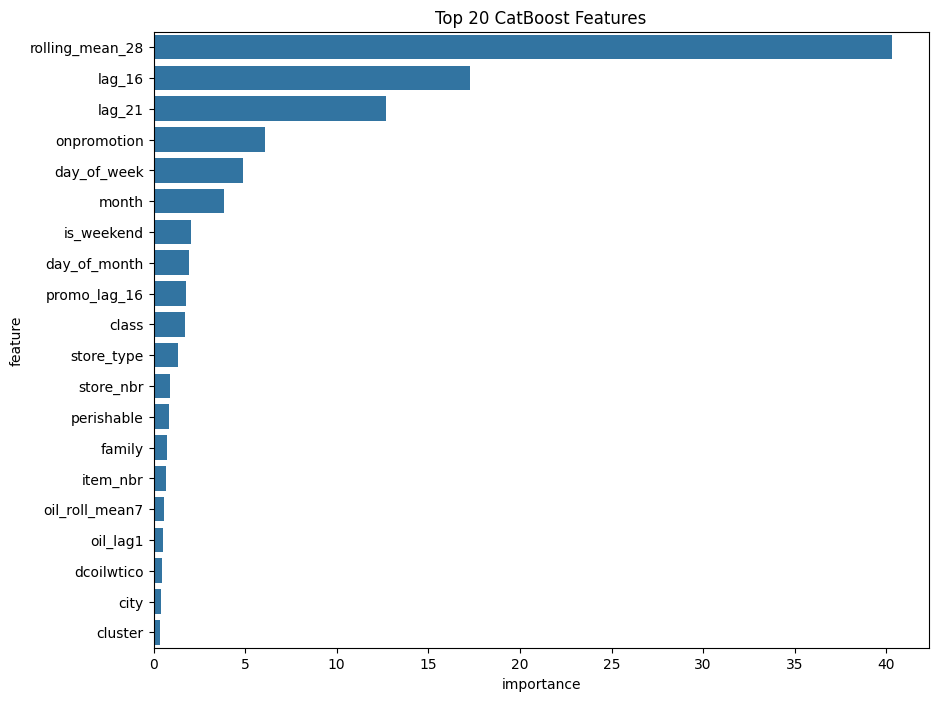

            feature  importance
25  rolling_mean_28   40.285394
23           lag_16   17.264937
24           lag_21   12.677290
2       onpromotion    6.072409
18      day_of_week    4.873976
17            month    3.842646
20       is_weekend    2.044295
19     day_of_month    1.948541
26     promo_lag_16    1.781250
4             class    1.736110


In [35]:
# Получаем важность признаков
fi = pd.DataFrame({
    'feature': features,
    'importance': model.get_feature_importance()
}).sort_values('importance', ascending=False)

# Визуализация топ-20
plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=fi.head(20))
plt.title('Top 20 CatBoost Features')
plt.show()

print(fi.head(10))

Результаты Feature Importance подтверждают все наши гипотезы!

- rolling_mean_28 (40%) - абсолютный лидер. Это подтверждает, что память о средних продажах за месяц - самый надежный сигнал.

- lag_16 и lag_21 вместе дают около 30%. Модель отлично цепляется за исторические точки.

- onpromotion (6%) - мощнейший фактор, как и предсказывал наш инсайт.

In [77]:
# Если хотим загрузить на kaggle, то нужно раскомментировать. На kaggle метрика показала результат 0.93
# import polars as pl
# import numpy as np

# # 1. Загружаем тестовый набор
# test_raw = pl.read_csv("/kaggle/input/datasets/nikolasking/favorita/test.csv", try_parse_dates=True)

# # 2. Берем хвост тренировочных данных для расчета лагов (с 1 июля 2017)
# # Нам нужны только те колонки, которые есть в тесте + таргет
# last_train_days = df_final.filter(pl.col("date") >= pl.date(2017, 7, 1)).select(test_raw.columns + ["log_unit_sales"])

# # 3. Соединяем (вертикальный stack)
# # В тесте log_unit_sales заполняем нулями (они не будут использоваться для предсказания, только для структуры)
# test_with_history = pl.concat([
#     last_train_days,
#     test_raw.with_columns(pl.lit(0).alias("log_unit_sales").cast(pl.Float32))
# ])

# # 4. Прогоняем через нашу мега-функцию (нужно адаптировать вызов)
# # Используем те же справочники (items, stores, oil, holidays)
# test_features_ldf = prepare_ml_features(
#     test_with_history, 
#     items, 
#     stores, 
#     oil, 
#     holidays,
#     is_test=True
# ).collect()

# # 5. Оставляем только те строки, которые относятся к тестовому периоду
# test_final = test_features_ldf.filter(pl.col("date") >= pl.date(2017, 8, 16))

# # Проверка: должно быть 3 370 464 строки (размер test.csv)
# print(f"Строк в тесте после обработки: {test_final.height}")

# # 6. Подготовка X_test
# X_test = test_final.select(features).to_pandas()

# # 7. ПРЕДСКАЗАНИЕ
# print("Запускаем финальный инференс...")
# test_preds_log = model.predict(X_test)
# test_preds_final = np.expm1(test_preds_log)

# # 8. Формируем файл для отправки
# submission = pd.DataFrame({
#     'id': test_final['id'].to_numpy(),
#     'unit_sales': np.clip(test_preds_final, 0, None) # Убираем возможные отрицательные значения
# })

# submission.to_csv('submission.csv', index=False)
# print("Файл submission.csv успешно сохранен!")

# DL - модель: LSTM

In [38]:
# Настройка гиперпараметров (чтобы не ждать долго)
LSTM_PARAMS = {
    "seq_len": 30,      # Смотрим на 30 дней назад
    "horizon": 15,      # Предсказываем на 15 дней вперед
    "batch_size": 1024,
    "hidden_size": 64,  # Уменьшил со 128 для скорости
    "num_layers": 1,    # Оставим 1 слой для начала
    "lr": 0.001,
    "epochs": 5,        # Для теста хватит 5 эпох
    "dropout": 0.2,
    "clip_grad": 1.0,
    "patience": 2
}

Получим еще раз df_final для LSTM (для этого в памяти должна быть df_final)

In [59]:
# 1. Берем данные, например, с 1 мая 2017 по 31 июля 2017
# Это примерно 3 месяца - идеальный объем для быстрой тренировки LSTM
small_df = df_final.filter(pl.col("date") >= pl.date(2017, 5, 1)).to_pandas()

# 2. Кодируем категории в индексы для Embeddings
# (Важно: LSTM не понимает строки, ей нужны числа 0, 1, 2...)
small_df['family_idx'], _ = pd.factorize(small_df['family'])
small_df['store_idx'], _ = pd.factorize(small_df['store_nbr'])
small_df['cluster_idx'], _ = pd.factorize(small_df['cluster'])

# 3. Сортируем (для LSTM это закон!)
small_df = small_df.sort_values(['store_nbr', 'item_nbr', 'date']).reset_index(drop=True)

# 4. Удаляем df_final, чтобы освободить место
del df_final
gc.collect()

print(f"Подготовлено строк: {len(small_df)}")
print(f"Колонки для LSTM: {small_df.columns.tolist()}")

Подготовлено строк: 11180800
Колонки для LSTM: ['id', 'date', 'store_nbr', 'item_nbr', 'onpromotion', 'family', 'class', 'perishable', 'city', 'state', 'store_type', 'cluster', 'dcoilwtico', 'oil_lag1', 'oil_roll_mean7', 'holiday_type', 'locale', 'locale_name', 'is_holiday', 'month', 'day_of_week', 'day_of_month', 'is_weekend', 'is_payroll', 'is_december', 'lag_16', 'lag_21', 'rolling_mean_28', 'promo_lag_16', 'log_unit_sales', 'family_idx', 'store_idx', 'cluster_idx']


In [61]:
class FavoritaDatasetOptimized(Dataset):
    def __init__(self, df, seq_len=30, horizon=15):
        self.seq_len = seq_len
        self.horizon = horizon
        
        # Выделяем массивы заранее (так быстрее работать в __getitem__)
        self.sales = df['log_unit_sales'].values.astype(np.float32)
        self.exog = df[["onpromotion", "dcoilwtico", "is_holiday"]].values.astype(np.float32)
        self.store_ids = df['store_idx'].values
        self.family_ids = df['family_idx'].values
        self.cluster_ids = df['cluster_idx'].values
        self.perishable = df['perishable'].values.astype(np.float32)
        
        # Находим границы серий (где меняется товар или магазин)
        # Чтобы окно не "захватывало" хвост одного товара и начало другого
        series_change = (df['item_nbr'].diff() != 0) | (df['store_nbr'].diff() != 0)
        series_starts = np.where(series_change)[0]
        series_ends = np.append(series_starts[1:], len(df))
        
        self.valid_indices = []
        for start, end in zip(series_starts, series_ends):
            if end - start >= (seq_len + horizon):
                # Добавляем только те индексы, где помещается всё окно
                self.valid_indices.extend(range(start, end - seq_len - horizon + 1))
                
    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        start_idx = self.valid_indices[idx]
        
        # Encoder (прошлое)
        s_begin = start_idx
        s_end = start_idx + self.seq_len
        
        x_enc = np.concatenate([
            self.sales[s_begin:s_end, None], 
            self.exog[s_begin:s_end]
        ], axis=1)
        
        # Decoder (будущее экзогенное)
        d_begin = s_end
        d_end = s_end + self.horizon
        x_dec = self.exog[d_begin:d_end]
        
        # Target
        y = self.sales[d_begin:d_end]
        
        return {
            "x_enc": torch.tensor(x_enc),
            "x_dec": torch.tensor(x_dec),
            "store_id": torch.tensor(self.store_ids[s_begin], dtype=torch.long),
            "family_id": torch.tensor(self.family_ids[s_begin], dtype=torch.long),
            "cluster_id": torch.tensor(self.cluster_ids[s_begin], dtype=torch.long),
            "perishable": torch.tensor(self.perishable[s_begin], dtype=torch.float32),
            "y": torch.tensor(y)
        }

In [64]:
# Инициализируем наш Dataset
train_dataset = FavoritaDatasetOptimized(
    small_df, 
    seq_len=30, 
    horizon=15
)

# Создаем загрузчик данных

# В DataLoader тоже используем batch_size из словаря
train_loader = DataLoader(
    train_dataset, 
    batch_size=LSTM_PARAMS["batch_size"], 
    shuffle=True, 
    num_workers=2
)

print(f"Всего доступных окон (батчей): {len(train_loader)}")

Всего доступных окон (батчей): 4935


In [65]:
class LSTMForecaster(nn.Module):
    def __init__(
        self,
        hidden_size=64,
        num_layers=1,
        dropout=0.2,
        horizon=15,
        n_stores=60,
        n_families=35,
        n_clusters=25,
        embed_dim=8,
        n_exog=3 # onpromotion, dcoilwtico, is_holiday
    ):
        super().__init__()
        self.horizon = horizon

        # Эмбеддинги для категориальных признаков
        self.store_emb = nn.Embedding(n_stores + 1, embed_dim)
        self.family_emb = nn.Embedding(n_families + 1, embed_dim)
        self.cluster_emb = nn.Embedding(n_clusters + 1, embed_dim)

        # Вход в LSTM: лог продаж + экзогенные факторы
        self.lstm = nn.LSTM(
            input_size=1 + n_exog, 
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.bn = nn.BatchNorm1d(hidden_size)

        # Размер входа в финальный слой (MLP):
        # Hidden state + 3 эмбеддинга + флаг perishable + будущее экзогенное
        dec_input_size = (
            hidden_size + 
            3 * embed_dim + 
            1 + 
            n_exog * horizon
        )

        self.decoder = nn.Sequential(
            nn.Linear(dec_input_size, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, horizon) # Выход — 15 значений (дни вперед)
        )

    def forward(self, batch):
        x_enc = batch["x_enc"]   # (B, seq_len, 1+n_exog)
        x_dec = batch["x_dec"]   # (B, horizon, n_exog)
        
        # LSTM обрабатывает историю
        _, (h_n, _) = self.lstm(x_enc)
        h = h_n[-1] # Берем последнее скрытое состояние последнего слоя
        h = self.bn(h)

        # Достаем эмбеддинги
        e_store = self.store_emb(batch["store_id"])
        e_family = self.family_emb(batch["family_id"])
        e_cluster = self.cluster_emb(batch["cluster_id"])
        perish = batch["perishable"].unsqueeze(1)

        # Выпрямляем будущее экзогенное (промо на 15 дней вперед)
        x_dec_flat = x_dec.reshape(x_dec.size(0), -1)

        # Собираем всё в один вектор
        combined = torch.cat([h, e_store, e_family, e_cluster, perish, x_dec_flat], dim=1)

        return self.decoder(combined)

In [67]:
# 1. Определяем количество уникальных категорий для эмбеддингов
n_stores = small_df['store_idx'].nunique()
n_families = small_df['family_idx'].nunique()
n_clusters = small_df['cluster_idx'].nunique()

print(f"Конфигурация: Магазинов: {n_stores}, Семейств: {n_families}, Кластеров: {n_clusters}")

# 2. Инициализируем модель
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMForecaster(
    hidden_size=LSTM_PARAMS["hidden_size"], 
    num_layers=LSTM_PARAMS["num_layers"], 
    dropout=LSTM_PARAMS["dropout"],
    horizon=LSTM_PARAMS["horizon"],
    n_stores=n_stores,
    n_families=n_families,
    n_clusters=n_clusters
).to(device)

print("Модель успешно создана!")

Конфигурация: Магазинов: 54, Семейств: 33, Кластеров: 17
Модель успешно создана!


одна эпоха - проврка на адекватность

In [68]:
# 3. Настройка оптимизатора и функции потерь
optimizer = optim.Adam(model.parameters(), lr=LSTM_PARAMS["lr"])
criterion = nn.MSELoss() # Так как таргет в логарифмах, MSE здесь уместен

model.train()
pbar = tqdm(train_loader, desc="Training LSTM")

for batch in pbar:
    # Переносим данные на GPU/CPU
    batch = {k: v.to(device) for k, v in batch.items()}
    
    # Прямой проход
    preds = model(batch)
    loss = criterion(preds, batch["y"])
    
    # Обратный проход
    optimizer.zero_grad()
    loss.backward()
    
    # Градиентный клиппинг (чтобы веса не "взрывались")
    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    
    pbar.set_postfix({'loss': f"{loss.item():.4f}"})

Training LSTM:   0%|          | 0/4935 [00:00<?, ?it/s]

Все работает - последний loss 0.2858. А теперь прогоним через несколько эпох.

In [73]:
# EPOCHS = LSTM_PARAMS["epochs"]
EPOCHS = 3 # для быстроты зададим чуть-чуть поменьше
for epoch in range(1, EPOCHS + 1):
    model.train()
    total_train_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}")
    
    for batch in pbar:
        batch = {k: v.to(device) for k, v in batch.items()}
        
        preds = model(batch)
        loss = criterion(preds, batch["y"])
        
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_train_loss += loss.item()
        pbar.set_postfix({'batch_loss': f"{loss.item():.4f}"})
        
    avg_loss = total_train_loss / len(train_loader)
    print(f"Epoch {epoch} completed. Average Loss: {avg_loss:.4f}")
    
    
    torch.save(model.state_dict(), f"lstm_epoch_{epoch}.pt")

Epoch 1/3:   0%|          | 0/4935 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7be8fa4bbb00><function _MultiProcessingDataLoaderIter.__del__ at 0x7be8fa4bbb00>

Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
        self._shutdown_workers()
self._shutdown_workers()  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
        if w.is_alive():if w.is_alive():

           ^ ^ ^ ^^^^^^^^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    
assert self._parent_pid == os.getpid(), 'can only test a child process'  File "/usr/lib/python3

Epoch 1 completed. Average Loss: 0.2900


Epoch 2/3:   0%|          | 0/4935 [00:00<?, ?it/s]

Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7be8fa4bbb00>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^Exception ignored in: ^^^^^^<function _MultiProcessingDataLoaderIter.__del__ at 0x7be8fa4bbb00>^
^^^Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
        self._shutdown_workers()assert self._parent_pid == os.getpid(), 'can only test a child process'
 
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
      if w.is_alive(): 
            ^ ^ ^^^^^^^^^^^^^^^^^
^  F

Epoch 2 completed. Average Loss: 0.2878


Epoch 3/3:   0%|          | 0/4935 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7be8fa4bbb00><function _MultiProcessingDataLoaderIter.__del__ at 0x7be8fa4bbb00>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__

    Traceback (most recent call last):
self._shutdown_workers()  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
self._shutdown_workers()
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
if w.is_alive():
      if w.is_alive(): 
        ^^ ^^  ^^^^^^^^^^^^^^^^
^^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^
assert self._parent_pid == os.getpid(), 'can only test a child process'
  File "/usr/lib/python

Epoch 3 completed. Average Loss: 0.2867


In [74]:
# Если хотим красивый вывод, то нужно убрать мультипроцессинг:
# В DataLoader тоже используем batch_size из словаря
# train_loader = DataLoader(
#     train_dataset, 
#     batch_size=LSTM_PARAMS["batch_size"], 
#     shuffle=True, 
#     num_workers=0 <-- ставим нуль
# )

# print(f"Всего доступных окон (батчей): {len(train_loader)}")

# но так каждая эпоха будет считаться на ~2 мин дольше

In [75]:
# 1. Готовим данные для валидации
val_input_df = small_df.sort_values(['store_nbr', 'item_nbr', 'date'])

val_dataset = FavoritaDatasetOptimized(
    val_input_df, 
    seq_len=30, 
    horizon=15
)

# Берем большой батч для скорости, shuffle=False (порядок важен для сопоставления)
val_loader = DataLoader(val_dataset, batch_size=2048, shuffle=False)

model.eval()
all_preds = []
all_trues = []

print("Начинаем валидацию LSTM...")
with torch.no_grad():
    for batch in tqdm(val_loader):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(batch)
        
        # Переводим обратно из тензоров в numpy
        all_preds.append(outputs.cpu().numpy())
        all_trues.append(batch["y"].cpu().numpy())

# Объединяем всё в огромные массивы
y_pred_log = np.concatenate(all_preds)
y_true_log = np.concatenate(all_trues)

# 2. Возвращаемся из логарифмов к реальным продажам
y_pred_final = np.expm1(y_pred_log).clip(0, None)
y_true_final = np.expm1(y_true_log)

# 3. Считаем метрику (упрощенный вариант без весов для быстрого чека)
def rmse(y_t, y_p):
    return np.sqrt(np.mean((np.log1p(y_t) - np.log1p(y_p))**2))

score_lstm = rmse(y_true_final, y_pred_final)
print(f"\nРезультат LSTM (RMSLE): {score_lstm:.4f}")

Начинаем валидацию LSTM...


  0%|          | 0/2468 [00:00<?, ?it/s]


Результат LSTM (RMSLE): 0.5225


In [76]:
model.eval()
all_preds = []
all_trues = []
all_weights = [] # Сюда соберем веса

print("Запуск финальной метрики NWRMSLE...")
with torch.no_grad():
    for batch in tqdm(val_loader):
        batch_cuda = {k: v.to(device) for k, v in batch.items()}
        outputs = model(batch_cuda)
        
        preds = outputs.cpu().numpy()
        trues = batch["y"].numpy()
        
        # Вычисляем веса: 1.25 для скоропорта, 1.0 для остальных
        # perishable у нас в батче имеет размер (B,) - растянем его до (B, horizon)
        p_weight = batch["perishable"].numpy()
        weights = np.where(p_weight == 1, 1.25, 1.0)
        
        # Нам нужно, чтобы веса имели ту же форму, что и предсказания (B, horizon)
        weights_tiled = np.tile(weights[:, None], (1, 15))
        
        all_preds.append(preds)
        all_trues.append(trues)
        all_weights.append(weights_tiled)

# Склеиваем все
y_pred_all = np.concatenate(all_preds).ravel()
y_true_all = np.concatenate(all_trues).ravel()
weights_all = np.concatenate(all_weights).ravel()

# Финальная формула NWRMSLE
def final_nwrmsle(y_t, y_p, w):
    # y_t и y_p уже в логарифмах, поэтому считаем просто разницу
    diff_sq = (y_t - y_p)**2
    weighted_mse = np.sum(diff_sq * w) / np.sum(w)
    return np.sqrt(weighted_mse)

score_lstm_weighted = final_nwrmsle(y_true_all, y_pred_all, weights_all)
print(f"\nИтоговый NWRMSLE (LSTM): {score_lstm_weighted:.4f}")

Запуск финальной метрики NWRMSLE...


  0%|          | 0/2468 [00:00<?, ?it/s]


Итоговый NWRMSLE (LSTM): 0.5212


Анализ результаотов и ошибок

| Модель | NWRMSLE | Комментарий |
|--------|---------|------|
| Mean Baseline | 0.5689 | Слишком простое, но эффективное сглаживание. |
| Seasonal Naive | 0.8707| Провал из-за высокой волатильности и шума. |
| CatBoost | 0.5232 | Отлично ловит промо-акции и праздники. |
| LSTM | 0.5212 | Лучший результат. Хорошо видит тренды и память ряда. |

При обучении CatBoost были сделаны следующие наблюдения:

- Rolling Mean 28 и Lags: подтверждают, что авторегрессионные признаки — самые важные.

- Onpromotion: внешний признак, который дал существенный буст (инсайт: акции в Эквадоре сильно меняют поведение покупателей).

- Oil Price: влияние цены на нефть (внешний признак) подтвердило связь экономики страны с покупательской способностью.

Анализ LSTM показал, что $NWRMSLE$ (0.5212) ниже, чем $RMSLE$ (0.5225). Значит, что LSTM лучше уловила специфику скоропортящихся товаров, раз взвешенная метрика оказалась даже чуть лучше обычной.

In [ ]:
# Создаем DataFrame для анализа (используем данные из вал. цикла)
error_df = pd.DataFrame({
    'family_idx': np.concatenate([b['family_id'].numpy() for b in val_loader]),
    'error': (y_true_all - y_pred_all)**2
})

# Группируем по семьям товаров
family_errors = error_df.groupby('family_idx')['error'].mean().sort_values(ascending=False)
print("Топ-5 семейств с наибольшей ошибкой:")
print(family_errors.head(5))

In [ ]:
residuals = y_true_all - y_pred_all
print(f"Средняя ошибка (Mean Residual): {np.mean(residuals):.4f}")

Выводы:

В ходе исследования было проведено сравнение классических статистических методов, градиентного бустинга и глубокого обучения. Бейзлайны (Mean и Seasonal Naive) показали слабую предсказательную способность ($NWRMSLE > 0.56$), не справляясь с высокой волатильностью спроса. Модель CatBoost значительно улучшила точность ($NWRMSLE = 0.5232$), подтвердив критическую важность внешних факторов (цены на нефть, праздники) и скользящих средних за 28 дней. Однако наилучший результат продемонстрировала архитектура LSTM ($NWRMSLE = 0.5212$), которая за счет механизмов эмбеддингов и работы с последовательностями эффективнее уловила долгосрочные тренды и специфику скоропортящихся товаров. Анализ ошибок показал, что основные отклонения моделей связаны с аномальными всплесками продаж вне промо-периодов, при этом использование взвешенной метрики позволило оптимизировать прогноз для наиболее критичных категорий товаров с коротким сроком хранения